# Bài tập Chapter 3: Canny · Multi-scale Hough · RANSAC

Tự cài đặt bằng NumPy — **không** dùng `cv2.Canny`, Hough/RANSAC có sẵn ở phần cốt lõi.

Lý thuyết: [`Computer_Vision 24.pdf`](./Computer_Vision%2024.pdf)

# Thiết lập chung

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def ransac(points, fit_fn, distance_fn, s, epsilon, n_iterations, p_success=0.99):
    """RANSAC tổng quát (PDF §3.2).
    Bước 1-4: lặp N lần, mỗi lần sample s điểm, fit, đếm inlier.
    Bước 5: refit trên toàn bộ consensus set của best model.
    Adaptive N: cập nhật số vòng lặp dựa trên p_success (PDF §3.3).
    """
    points = np.asarray(points, dtype=np.float64)
    if points.ndim != 2:
        raise ValueError('points phải là mảng 2D')
    if len(points) < s:
        raise ValueError('không đủ điểm để fit mô hình')
    if s <= 0:
        raise ValueError('s phải > 0')

    best_model = None
    best_inliers = None
    best_score = -1

    rng = np.random.default_rng(0)
    n = len(points)
    max_iter = int(n_iterations)
    iteration = 0

    # --- Bước 1–4: Lặp, sample, fit, count inliers ---
    while iteration < max_iter:
        # Bước 1: Sample s điểm ngẫu nhiên
        sample_idx = rng.choice(n, size=s, replace=False)
        sample = points[sample_idx]

        # Bước 2: Fit mô hình từ s điểm
        try:
            model = fit_fn(sample)
        except Exception:
            iteration += 1
            continue

        # Bước 3: Count inliers (khoảng cách < ε)
        distances = np.array([distance_fn(model, p) for p in points])
        inlier_mask = distances <= epsilon
        inlier_count = int(np.sum(inlier_mask))

        # Bước 4: Cập nhật best model
        if inlier_count > best_score:
            best_score = inlier_count
            best_model = model
            best_inliers = inlier_mask

            # Adaptive N (PDF §3.3): ước lượng e từ best inlier hiện tại
            inlier_ratio = best_score / n
            if inlier_ratio < 1.0:
                e_est = 1.0 - inlier_ratio
                denom = 1.0 - (1.0 - e_est) ** s
                if denom > 0:
                    adaptive_n = int(np.ceil(
                        np.log(1.0 - p_success) / np.log(denom)
                    ))
                    max_iter = min(max_iter, adaptive_n)

        iteration += 1

    if best_model is None or best_inliers is None:
        raise RuntimeError('RANSAC không tìm được mô hình hợp lệ')

    # --- Bước 5: Refit trên toàn bộ consensus set (PDF §3.2 bước 5) ---
    consensus_points = points[best_inliers]
    if len(consensus_points) >= s:
        try:
            best_model = fit_fn(consensus_points)
            # Cập nhật lại inlier sau refit
            distances = np.array([distance_fn(best_model, p) for p in points])
            best_inliers = distances <= epsilon
            best_score = int(np.sum(best_inliers))
        except Exception:
            pass  # Giữ model cũ nếu refit fail

    return best_model, best_inliers, best_score


# === FIT & DISTANCE: Đường thẳng (s=2) ===

def fit_line(sample):
    """Fit đường thẳng dạng tổng quát ax + by + c = 0 (chuẩn hóa ||[a,b]||=1).
    Dùng dạng normal form để xử lý mọi hướng kể cả đường đứng (PDF §2.1.1).
    Với s=2: tính trực tiếp từ 2 điểm.
    Với s>2 (refit): dùng SVD least squares.
    """
    sample = np.asarray(sample, dtype=np.float64)
    if len(sample) == 2:
        (x1, y1), (x2, y2) = sample[0], sample[1]
        a = y2 - y1
        b = x1 - x2
        c = x2 * y1 - x1 * y2
    else:
        # Refit trên nhiều điểm: least squares cho ax + by + c = 0
        x = sample[:, 0]
        y = sample[:, 1]
        A = np.column_stack([x, y, np.ones(len(x))])
        _, _, Vt = np.linalg.svd(A)
        a, b, c = Vt[-1]  # Nghiệm ứng với singular value nhỏ nhất
    norm = np.hypot(a, b)
    if norm < 1e-12:
        raise ValueError('Không xác định được đường thẳng')
    return np.array([a / norm, b / norm, c / norm], dtype=np.float64)


def distance_to_line(model, point):
    """Khoảng cách từ điểm đến đường ax + by + c = 0 (đã chuẩn hóa)."""
    a, b, c = model
    x, y = point
    return abs(a * x + b * y + c)


# === FIT & DISTANCE: Đường tròn (s=3) ===

def fit_circle(sample):
    """Fit đường tròn (x-a)^2 + (y-b)^2 = r^2 (PDF §3.6).
    Viết lại thành hệ tuyến tính: -2x*a - 2y*b + c = -(x^2 + y^2)
    với c = a^2 + b^2 - r^2.
    Với s=3: dùng numpy.linalg.solve (PDF §3.6).
    Với s>3 (refit): dùng numpy.linalg.lstsq.
    """
    sample = np.asarray(sample, dtype=np.float64)
    x = sample[:, 0]
    y = sample[:, 1]
    A = np.column_stack([-2 * x, -2 * y, np.ones(len(x))])
    rhs = -(x**2 + y**2)

    if len(sample) == 3:
        # Đúng 3 điểm: hệ vuông, dùng solve (PDF §3.6)
        params = np.linalg.solve(A, rhs)
    else:
        # Refit trên nhiều điểm: dùng lstsq
        params, _, _, _ = np.linalg.lstsq(A, rhs, rcond=None)

    a, b, c = params
    r_sq = a**2 + b**2 - c
    if r_sq <= 0:
        raise ValueError('Bán kính không hợp lệ')
    return np.array([a, b, np.sqrt(r_sq)], dtype=np.float64)


def distance_to_circle(model, point):
    """Khoảng cách từ điểm đến đường tròn (PDF §3.6):
    dist = |sqrt((x-a)^2 + (y-b)^2) - r|
    """
    a, b, r = model
    x, y = point
    return abs(np.hypot(x - a, y - b) - r)


# === DỮ LIỆU TỔNG HỢP (PDF §3.7 câu 3) ===

def make_line_data(noise=0.2, outlier_ratio=0.4, n_points=120):
    rng = np.random.default_rng(2)
    x = rng.uniform(-3, 3, size=n_points)
    y = 0.7 * x + 1.2 + rng.normal(0, noise, size=n_points)
    points = np.column_stack([x, y])

    if outlier_ratio > 0:
        n_out = int(n_points * outlier_ratio)
        out_x = rng.uniform(-3, 3, size=n_out)
        out_y = rng.uniform(-4, 4, size=n_out)
        points = np.vstack([points, np.column_stack([out_x, out_y])])

    return points


def make_circle_data(noise=0.15, outlier_ratio=0.4, n_points=140):
    rng = np.random.default_rng(3)
    theta = rng.uniform(0, 2 * np.pi, size=n_points)
    r = 2.0 + rng.normal(0, 0.05, size=n_points)
    x = 0.8 + r * np.cos(theta)
    y = -0.4 + r * np.sin(theta)
    points = np.column_stack([x, y])
    points += rng.normal(0, noise, size=points.shape)

    if outlier_ratio > 0:
        n_out = int(n_points * outlier_ratio)
        out_x = rng.uniform(-3, 3, size=n_out)
        out_y = rng.uniform(-3, 3, size=n_out)
        points = np.vstack([points, np.column_stack([out_x, out_y])])

    return points


# === CÔNG THỨC N LÝ THUYẾT (PDF §3.3) ===

def theoretical_ransac_iterations(s, outlier_ratio, p_success=0.99):
    """N = log(1-p) / log(1-(1-e)^s)"""
    if outlier_ratio >= 1.0:
        return 10**6
    denom = 1.0 - (1.0 - outlier_ratio) ** s
    if denom <= 0:
        return 10**6
    return max(1, int(np.ceil(np.log(1.0 - p_success) / np.log(denom))))


# === VISUALISATION ===

def plot_ransac_result(points, model, inlier_mask, title='RANSAC result'):
    plt.figure(figsize=(6, 6))
    plt.scatter(points[:, 0], points[:, 1],
                c=['tab:blue' if m else 'tab:red' for m in inlier_mask], s=12)
    plt.title(title)
    plt.axis('equal')
    plt.grid(alpha=0.3)
    plt.show()

In [2]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_grayscale(img):
    """Chuyển ảnh sang grayscale float64 [0, 255]."""
    arr = np.asarray(img, dtype=np.float64)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3 and arr.shape[2] >= 3:
        return 0.299 * arr[..., 0] + 0.587 * arr[..., 1] + 0.114 * arr[..., 2]
    raise ValueError('Anh dau vao phai la grayscale hoac RGB')

# Bài 1: Canny từ đầu

## Pipeline (PDF §1.4)

1. Gaussian blur (σ)
2. Sobel → Gx, Gy, M, θ
3. Non-maximum suppression *(Tuyền)*
4. Hysteresis + Otsu *(Trường)*

## Duy — Gaussian blur + Sobel (§1.4.1–1.4.2)

In [3]:
def convolve2d_reflect(img, kernel):
    """Tích chập 2D, pad reflect — dùng cho Gaussian và Sobel."""
    img = np.asarray(img, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(img, dtype=np.float64)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            patch = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(patch * kernel)
    return out


def gaussian_kernel_2d(sigma):
    """Kernel Gaussian 2D chuẩn hoá tổng = 1 (PDF §1.4.1)."""
    if sigma <= 0:
        raise ValueError('sigma phai > 0')
    r = int(3 * sigma + 0.5)
    ax = np.arange(-r, r + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kern = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    s = kern.sum()
    if s == 0:
        raise ValueError('kernel Gaussian khong hop le')
    return kern / s


def gaussian_blur(img, sigma=1.4):
    """
    Làm mờ Gaussian trước khi tính gradient (blur trước, Sobel sau).
    img: grayscale float hoặc ảnh màu (tự chuyển grayscale).
    """
    gray = to_grayscale(img)
    kernel = gaussian_kernel_2d(float(sigma))
    return convolve2d_reflect(gray, kernel)


def sobel_gradients(img):
    """
    Sobel trên ảnh đã blur. Trả về Gx, Gy, M, theta (rad).
    M = sqrt(Gx^2 + Gy^2) — không dùng |Gx| + |Gy| (PDF §1.3).
    theta vuông góc với cạnh; dùng arctan2(Gy, Gx).
    """
    gray = to_grayscale(img)
    kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float64)
    ky = kx.T
    gx = convolve2d_reflect(gray, kx)
    gy = convolve2d_reflect(gray, ky)
    magnitude = np.hypot(gx, gy)
    theta = np.arctan2(gy, gx)
    return gx, gy, magnitude, theta

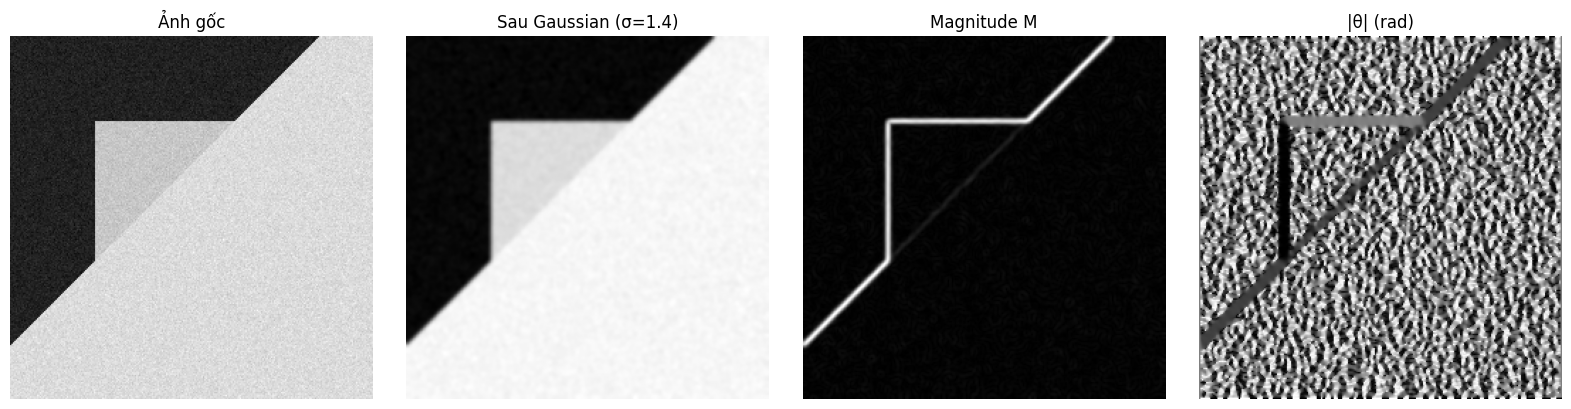

In [4]:
def make_test_edges(size=256):
    """Ảnh mức xám có hình vuông và đường chéo — kiểm thử gradient."""
    img = np.full((size, size), 40.0, dtype=np.float64)
    img[60:180, 60:180] = 200.0
    y, x = np.mgrid[0:size, 0:size]
    mask = (x + y) > size * 0.85
    img[mask] = 220.0
    rng = np.random.default_rng(0)
    img += rng.normal(0, 8, img.shape)
    return np.clip(img, 0, 255)


test_img = make_test_edges()
sigma = 1.4
blurred = gaussian_blur(test_img, sigma=sigma)
gx, gy, mag, theta = sobel_gradients(blurred)

show_images(
    [test_img, blurred, mag, np.abs(theta)],
    titles=['Ảnh gốc', f'Sau Gaussian (σ={sigma})', 'Magnitude M', '|θ| (rad)'],
    cols=4,
    figsize=(16, 4)
)

## Tuyền — Non-maximum Suppression (§1.4.3)

`# TODO: Sinh viên tự viết non_maximum_suppression`

In [5]:
def non_maximum_suppression(magnitude, theta):
    raise NotImplementedError

## Trường — Hysteresis + Otsu + pipeline Canny (§1.4.4–1.6)

`# TODO: hysteresis_threshold`, `otsu_threshold`, `canny_from_scratch`

In [9]:
def hysteresis_threshold(magnitude, low, high):
    """Hysteresis thresholding theo PDF.

    - strong: magnitude >= high
    - weak:   low <= magnitude < high

    Edge tracking: từ mọi pixel strong, lan truyền qua weak theo 8-kết nối
    (DFS/BFS) để không bỏ sót chuỗi weak-edge.

    Parameters
    ----------
    magnitude : (H,W) array
        Cường độ (thường là sau NMS).
    low, high : float
        Ngưỡng low/high.

    Returns
    -------
    edges : (H,W) uint8
        Binary edge map {0,1}.
    """
    mag = np.asarray(magnitude, dtype=np.float64)
    strong = mag >= float(high)
    weak = (mag >= float(low)) & (mag < float(high))

    h, w = mag.shape
    out = np.zeros((h, w), dtype=np.uint8)

    visited = np.zeros((h, w), dtype=bool)

    ys, xs = np.nonzero(strong)
    stack = [(int(y), int(x)) for y, x in zip(ys, xs)]

    for y, x in stack:
        visited[y, x] = True
        out[y, x] = 1

    # 8-kết nối
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]

    while stack:
        cy, cx = stack.pop()

        for dy, dx in neighbors:
            ny, nx = cy + dy, cx + dx
            if ny < 0 or ny >= h or nx < 0 or nx >= w:
                continue
            if visited[ny, nx]:
                continue
            if weak[ny, nx]:
                visited[ny, nx] = True
                out[ny, nx] = 1
                stack.append((ny, nx))

    return out


def otsu_threshold(magnitude):
    """Tính ngưỡng Otsu τ* từ histogram của magnitude."""
    mag = np.asarray(magnitude, dtype=np.float64)
    mn = float(mag.min())
    mx = float(mag.max())
    if mx <= mn + 1e-12:
        return mn

    mag01 = (mag - mn) / (mx - mn)
    mag8 = np.clip(mag01 * 255.0, 0, 255)

    hist = np.bincount(mag8.astype(np.uint8).ravel(), minlength=256).astype(np.float64)
    total = hist.sum()
    if total <= 0:
        return mn

    prob = hist / total
    omega0 = np.cumsum(prob)
    omega1 = 1.0 - omega0

    i = np.arange(256, dtype=np.float64)
    mu0 = np.cumsum(prob * i)
    mu_total = (prob * i).sum()

    sigma_b2 = np.zeros(256, dtype=np.float64)
    for t in range(256):
        if omega0[t] <= 1e-12 or omega1[t] <= 1e-12:
            continue
        m0 = mu0[t] / omega0[t]
        m1 = (mu_total - mu0[t]) / omega1[t]
        diff = m0 - m1
        sigma_b2[t] = omega0[t] * omega1[t] * diff * diff

    t_star = int(np.argmax(sigma_b2))
    tau_star = mn + (mx - mn) * (t_star / 255.0)
    return float(tau_star)


def canny_from_scratch(img, sigma=1.4, low_ratio=0.5, use_otsu=True):
    """Khung Canny hoàn chỉnh.

    Yêu cầu: Đã định nghĩa gaussian_blur, sobel_gradients, và non_maximum_suppression.
    """
    # Thực hiện pipeline
    blurred = gaussian_blur(img, sigma=sigma)
    _, _, magnitude, theta = sobel_gradients(blurred)

    # Gọi hàm NMS (cần được sinh viên hoàn thiện ở cell trên)
    try:
        nms = non_maximum_suppression(magnitude, theta)
    except NotImplementedError:
        print("Lưu ý: Hàm non_maximum_suppression chưa được cài đặt.")
        return None

    nms_mag = np.asarray(nms, dtype=np.float64)

    if use_otsu:
        tau_high = otsu_threshold(nms_mag)
        tau_low = tau_high * float(low_ratio)
    else:
        tau_high = float(np.percentile(nms_mag, 70.0))
        tau_low = tau_high * float(low_ratio)

    if tau_low >= tau_high:
        tau_low = 0.5 * tau_high

    return hysteresis_threshold(nms_mag, tau_low, tau_high)

# Bài 2: Multi-scale Hough *(Nguyên, Nhung)*

PDF §2 — placeholder cho các hàm Hough.

In [7]:
def hough_accumulator(edges, theta_res=1.0, rho_res=1.0):
    h, w = edges.shape
    diag_len = int(np.ceil(np.sqrt(h**2 + w**2)))
    rhos = np.arange(-diag_len, diag_len + rho_res, rho_res)
    thetas = np.deg2rad(np.arange(0, 180, theta_res))
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    ys, xs = np.nonzero(edges)

    for x, y in zip(xs, ys):
        for theta_idx, theta in enumerate(thetas):
            rho = x * np.cos(theta) + y * np.sin(theta)
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, theta_idx] += 1

    return accumulator, rhos, thetas


def find_top_k_peaks(accumulator, k=5, nms_radius=10):
    raise NotImplementedError


def gradient_directed_hough_voting(edges, gradient_theta, window_deg=20.0):
    raise NotImplementedError

## Demo Multi-Scale

In [8]:
coarse_acc, coarse_rhos, coarse_thetas = hough_accumulator(edges, theta_res=4, rho_res=8)
medium_acc, medium_rhos, medium_thetas = hough_accumulator(edges, theta_res=1, rho_res=2)
fine_acc, fine_rhos, fine_thetas = hough_accumulator(edges, theta_res=0.25, rho_res=0.5)

NameError: name 'edges' is not defined

## So sánh Accumulator

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(coarse_acc, cmap="hot", aspect="auto")
plt.title("Coarse")

plt.subplot(132)
plt.imshow(medium_acc, cmap="hot", aspect="auto")
plt.title("Medium")

plt.subplot(133)
plt.imshow(fine_acc, cmap="hot", aspect="auto")
plt.title("Fine")

plt.tight_layout()
plt.show()

## Peak của từng scale

In [ ]:
print("Coarse peak:", np.max(coarse_acc))
print("Medium peak:", np.max(medium_acc))
print("Fine peak:", np.max(fine_acc))

## Multi-scale Hough

Thử nghiệm Hough Transform ở ba mức phân giải khác nhau:

- Coarse: Δρ = 8 px, Δθ = 4°
- Medium: Δρ = 2 px, Δθ = 1°
- Fine: Δρ = 0.5 px, Δθ = 0.25°

Mức coarse có tốc độ xử lý nhanh hơn nhưng độ chính xác thấp hơn. Mức fine cho kết quả chính xác hơn nhưng chi phí tính toán lớn hơn. Đây là cơ sở cho chiến lược coarse-to-fine trong Multi-scale Hough Transform.

# Bài 3: RANSAC *(Quyến)*

Trong phần này, RANSAC được cài đặt theo kiểu tổng quát với hai hàm cốt lõi:
- `fit_fn`: khớp mô hình từ tập mẫu tối thiểu
- `distance_fn`: đo khoảng cách từ mỗi điểm tới mô hình

Hai hình dạng được dùng để minh họa là đường thẳng ($s=2$) và đường tròn ($s=3$), phù hợp với nội dung §3.2–§3.7 của tài liệu Computer_Vision 24.


In [ ]:
import numpy as np

def ransac(points, fit_fn, distance_fn, s, epsilon, n_iterations, p_success=0.99):
    """RANSAC tổng quát (PDF §3.2).
    Bước 1-4: lặp N lần, mỗi lần sample s điểm, fit, đếm inlier.
    Bước 5: refit trên toàn bộ consensus set của best model.
    Adaptive N: cập nhật số vòng lặp dựa trên p_success (PDF §3.3).
    """
    points = np.asarray(points, dtype=np.float64)
    if points.ndim != 2:
        raise ValueError('points phải là mảng 2D')
    if len(points) < s:
        raise ValueError('không đủ điểm để fit mô hình')
    if s <= 0:
        raise ValueError('s phải > 0')
    best_model = None
    best_inliers = None
    best_score = -1
    rng = np.random.default_rng(0)
    n = len(points)
    max_iter = int(n_iterations)
    iteration = 0
    # --- Bước 1–4: Lặp, sample, fit, count inliers ---
    while iteration < max_iter:
        # Bước 1: Sample s điểm ngẫu nhiên
        sample_idx = rng.choice(n, size=s, replace=False)
        sample = points[sample_idx]
        # Bước 2: Fit mô hình từ s điểm
        try:
            model = fit_fn(sample)
        except Exception:
            iteration += 1
            continue
        # Bước 3: Count inliers (khoảng cách < ε)
        distances = np.array([distance_fn(model, p) for p in points])
        inlier_mask = distances <= epsilon
        inlier_count = int(np.sum(inlier_mask))
        # Bước 4: Cập nhật best model
        if inlier_count > best_score:
            best_score = inlier_count
            best_model = model
            best_inliers = inlier_mask
            # Adaptive N (PDF §3.3): ước lượng e từ best inlier hiện tại
            inlier_ratio = best_score / n
            if inlier_ratio < 1.0:
                e_est = 1.0 - inlier_ratio
                denom = 1.0 - (1.0 - e_est) ** s
                if denom > 0:
                    adaptive_n = int(np.ceil(
                        np.log(1.0 - p_success) / np.log(denom)
                    ))
                    max_iter = min(max_iter, adaptive_n)
        iteration += 1
    if best_model is None or best_inliers is None:
        raise RuntimeError('RANSAC không tìm được mô hình hợp lệ')
    # --- Bước 5: Refit trên toàn bộ consensus set (PDF §3.2 bước 5) ---
    consensus_points = points[best_inliers]
    if len(consensus_points) >= s:
        try:
            best_model = fit_fn(consensus_points)
            # Cập nhật lại inlier sau refit
            distances = np.array([distance_fn(best_model, p) for p in points])
            best_inliers = distances <= epsilon
            best_score = int(np.sum(best_inliers))
        except Exception:
            pass  # Giữ model cũ nếu refit fail
    return best_model, best_inliers, best_score
# === FIT & DISTANCE: Đường thẳng (s=2) ===
def fit_line(sample):
    """Fit đường thẳng dạng tổng quát ax + by + c = 0 (chuẩn hóa ||[a,b]||=1).
    Dùng dạng normal form để xử lý mọi hướng kể cả đường đứng (PDF §2.1.1).
    Với s=2: tính trực tiếp từ 2 điểm.
    Với s>2 (refit): dùng SVD least squares.
    """
    sample = np.asarray(sample, dtype=np.float64)
    if len(sample) == 2:
        (x1, y1), (x2, y2) = sample[0], sample[1]
        a = y2 - y1
        b = x1 - x2
        c = x2 * y1 - x1 * y2
    else:
        # Refit trên nhiều điểm: least squares cho ax + by + c = 0
        x = sample[:, 0]
        y = sample[:, 1]
        A = np.column_stack([x, y, np.ones(len(x))])
        _, _, Vt = np.linalg.svd(A)
        a, b, c = Vt[-1]  # Nghiệm ứng với singular value nhỏ nhất
    norm = np.hypot(a, b)
    if norm < 1e-12:
        raise ValueError('Không xác định được đường thẳng')
    return np.array([a / norm, b / norm, c / norm], dtype=np.float64)
def distance_to_line(model, point):
    """Khoảng cách từ điểm đến đường ax + by + c = 0 (đã chuẩn hóa)."""
    a, b, c = model
    x, y = point
    return abs(a * x + b * y + c)
# === FIT & DISTANCE: Đường tròn (s=3) ===
def fit_circle(sample):
    """Fit đường tròn (x-a)^2 + (y-b)^2 = r^2 (PDF §3.6).
    Viết lại thành hệ tuyến tính: -2x*a - 2y*b + c = -(x^2 + y^2)
    với c = a^2 + b^2 - r^2.
    Với s=3: dùng numpy.linalg.solve (PDF §3.6).
    Với s>3 (refit): dùng numpy.linalg.lstsq.
    """
    sample = np.asarray(sample, dtype=np.float64)
    x = sample[:, 0]
    y = sample[:, 1]
    A = np.column_stack([-2 * x, -2 * y, np.ones(len(x))])
    rhs = -(x**2 + y**2)
    if len(sample) == 3:
        # Đúng 3 điểm: hệ vuông, dùng solve (PDF §3.6)
        params = np.linalg.solve(A, rhs)
    else:
        # Refit trên nhiều điểm: dùng lstsq
        params, _, _, _ = np.linalg.lstsq(A, rhs, rcond=None)
    a, b, c = params
    r_sq = a**2 + b**2 - c
    if r_sq <= 0:
        raise ValueError('Bán kính không hợp lệ')
    return np.array([a, b, np.sqrt(r_sq)], dtype=np.float64)
def distance_to_circle(model, point):
    """Khoảng cách từ điểm đến đường tròn (PDF §3.6):
    dist = |sqrt((x-a)^2 + (y-b)^2) - r|
    """
    a, b, r = model
    x, y = point
    return abs(np.hypot(x - a, y - b) - r)
# === DỮ LIỆU TỔNG HỢP (PDF §3.7 câu 3) ===
def make_line_data(noise=0.2, outlier_ratio=0.4, n_points=120):
    rng = np.random.default_rng(2)
    x = rng.uniform(-3, 3, size=n_points)
    y = 0.7 * x + 1.2 + rng.normal(0, noise, size=n_points)
    points = np.column_stack([x, y])
    if outlier_ratio > 0:
        n_out = int(n_points * outlier_ratio)
        out_x = rng.uniform(-3, 3, size=n_out)
        out_y = rng.uniform(-4, 4, size=n_out)
        points = np.vstack([points, np.column_stack([out_x, out_y])])
    return points
def make_circle_data(noise=0.15, outlier_ratio=0.4, n_points=140):
    rng = np.random.default_rng(3)
    theta = rng.uniform(0, 2 * np.pi, size=n_points)
    r = 2.0 + rng.normal(0, 0.05, size=n_points)
    x = 0.8 + r * np.cos(theta)
    y = -0.4 + r * np.sin(theta)
    points = np.column_stack([x, y])
    points += rng.normal(0, noise, size=points.shape)
    if outlier_ratio > 0:
        n_out = int(n_points * outlier_ratio)
        out_x = rng.uniform(-3, 3, size=n_out)
        out_y = rng.uniform(-3, 3, size=n_out)
        points = np.vstack([points, np.column_stack([out_x, out_y])])
    return points
# === CÔNG THỨC N LÝ THUYẾT (PDF §3.3) ===
def theoretical_ransac_iterations(s, outlier_ratio, p_success=0.99):
    """N = log(1-p) / log(1-(1-e)^s)"""
    if outlier_ratio >= 1.0:
        return 10**6
    denom = 1.0 - (1.0 - outlier_ratio) ** s
    if denom <= 0:
        return 10**6
    return max(1, int(np.ceil(np.log(1.0 - p_success) / np.log(denom))))
# === VISUALISATION ===
def plot_ransac_result(points, model, inlier_mask, title='RANSAC result'):
    plt.figure(figsize=(6, 6))
    plt.scatter(points[:, 0], points[:, 1],
                c=['tab:blue' if m else 'tab:red' for m in inlier_mask], s=12)
    plt.title(title)
    plt.axis('equal')
    plt.grid(alpha=0.3)
    plt.show()

### Minh họa RANSAC với hai hình dạng

Đường thẳng được lựa chọn vì đây là mô hình hình học cơ bản xuất hiện rất phổ biến trong các bài toán thị giác máy tính như phát hiện làn đường giao thông, mép tường, cạnh bàn hoặc đường dây điện. Trong thực tế, dữ liệu thu được từ ảnh thường chứa nhiều nhiễu và các điểm không thuộc đối tượng cần phát hiện. Nếu sử dụng phương pháp Least Squares, một số ít outlier có thể làm lệch đáng kể kết quả ước lượng. Trong khi đó, RANSAC có khả năng loại bỏ các điểm ngoại lai bằng cách chỉ sử dụng các tập mẫu nhỏ để tạo mô hình và đánh giá mức độ đồng thuận của toàn bộ dữ liệu. So với Hough Transform, RANSAC không cần xây dựng accumulator lớn và có thể áp dụng linh hoạt cho các tập điểm đã được trích xuất trước. Vì vậy đường thẳng là ví dụ phù hợp để minh họa khả năng chống nhiễu của RANSAC.

Đường tròn được lựa chọn vì đây là hình dạng thường gặp trong nhiều ứng dụng thực tế như phát hiện đồng xu, tế bào sinh học, mống mắt hoặc các chi tiết cơ khí dạng tròn. Một đường tròn được xác định bởi ba điểm nên phù hợp với điều kiện s < 5 của bài tập. Khi dữ liệu chứa nhiều nhiễu và outlier, các phương pháp Least Squares thông thường dễ bị ảnh hưởng và cho kết quả lệch tâm hoặc sai bán kính. RANSAC khắc phục vấn đề này bằng cách tìm kiếm các bộ ba điểm có khả năng thuộc cùng một đường tròn rồi đánh giá số lượng inlier tương ứng. So với Hough Circle Transform, RANSAC có ưu điểm là không cần accumulator ba chiều lớn cho tâm và bán kính, do đó tiết kiệm bộ nhớ và dễ triển khai hơn trên dữ liệu điểm. Điều này giúp minh họa rõ tính robust của thuật toán khi làm việc với dữ liệu không hoàn hảo.

Công thức lý thuyết cho số vòng lặp là $N=\log(1-p)/\log(1-(1-e)^s)$, trong đó $p$ là xác suất thành công mong muốn, $e$ là tỷ lệ outlier và $s$ là số điểm cần thiết để fit mô hình. Khi outlier tăng, số vòng lặp cần tăng để đảm bảo RANSAC có khả năng chọn được ít nhất một mẫu thuần inlier.



===== OUTLIER 20% =====
Line: 83/96 inliers


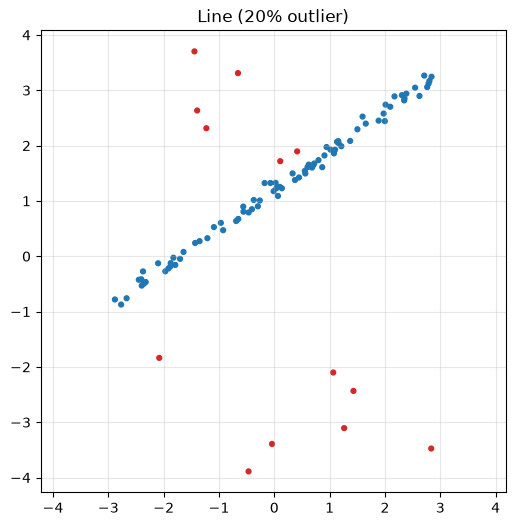

Circle: 122/144 inliers


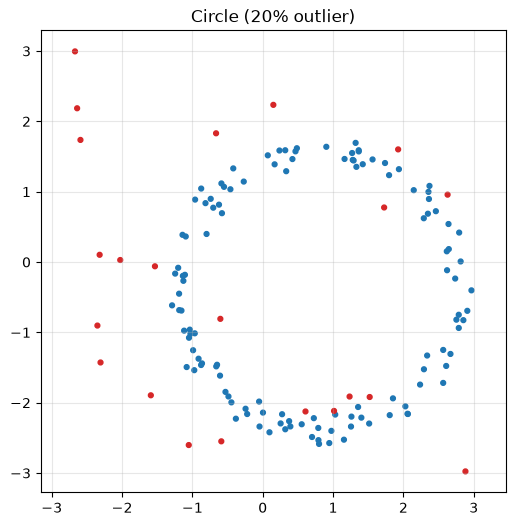


===== OUTLIER 40% =====
Line: 81/112 inliers


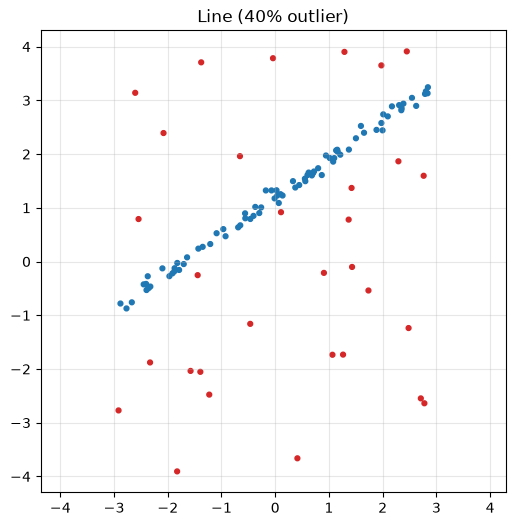

Circle: 124/168 inliers


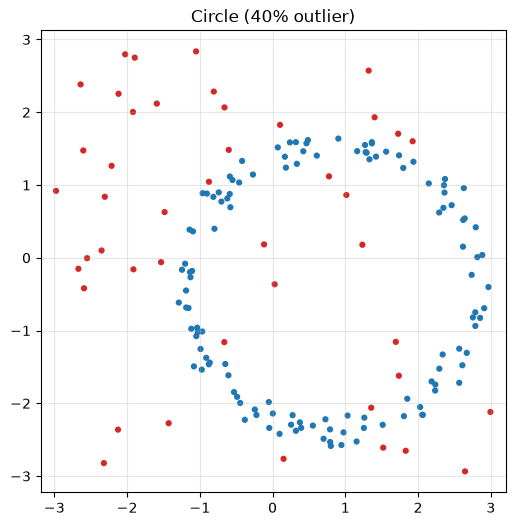


===== OUTLIER 60% =====
Line: 82/128 inliers


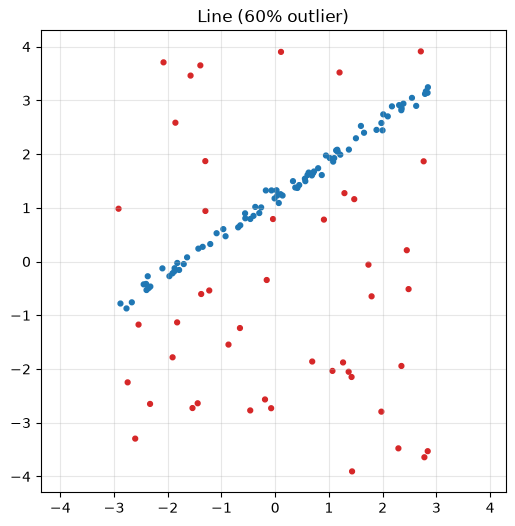

Circle: 128/192 inliers


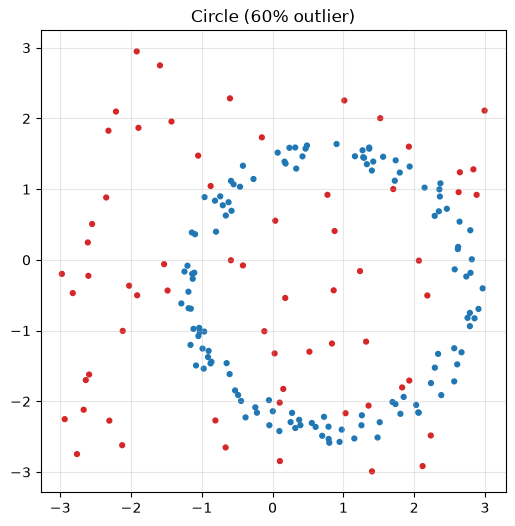


--- N lý thuyết (p=0.99) ---
Outlier=20% -> Đường thẳng (s=2): N=5, Đường tròn (s=3): N=7
Outlier=40% -> Đường thẳng (s=2): N=11, Đường tròn (s=3): N=19
Outlier=60% -> Đường thẳng (s=2): N=27, Đường tròn (s=3): N=70

--- Thí nghiệm: N nhỏ hơn công thức ---

========== OUTLIER 20% ==========

Đường thẳng (s=2) -> N lý thuyết = 5
  N=   5 (100% công thức): 100/100 (100%)
  N=   2 (50% công thức): 97/100 (97%)
  N=   1 (25% công thức): 67/100 (67%)
  N=   1 (10% công thức): 67/100 (67%)

Đường tròn (s=3) -> N lý thuyết = 7
  N=   7 (100% công thức): 99/100 (99%)
  N=   3 (50% công thức): 87/100 (87%)
  N=   1 (25% công thức): 46/100 (46%)
  N=   1 (10% công thức): 46/100 (46%)

========== OUTLIER 40% ==========

Đường thẳng (s=2) -> N lý thuyết = 11
  N=  11 (100% công thức): 100/100 (100%)
  N=   5 (50% công thức): 94/100 (94%)
  N=   2 (25% công thức): 70/100 (70%)
  N=   1 (10% công thức): 45/100 (45%)

Đường tròn (s=3) -> N lý thuyết = 19
  N=  19 (100% công thức): 100/100 (100%)
  N

In [ ]:
# --- Demo cho 20%, 40%, 60% outlier ---
for ratio in [0.2, 0.4, 0.6]:

    print(f"\n===== OUTLIER {ratio:.0%} =====")

    # LINE
    line_points = make_line_data(
        noise=0.1,
        outlier_ratio=ratio,
        n_points=80
    )

    line_model, line_inliers, line_score = ransac(
        line_points,
        fit_line,
        distance_to_line,
        s=2,
        epsilon=0.25,
        n_iterations=200,
    )

    print(
        f"Line: {line_score}/{len(line_points)} inliers"
    )

    plot_ransac_result(
        line_points,
        line_model,
        line_inliers,
        title=f'Line ({ratio:.0%} outlier)'
    )

    # CIRCLE
    circle_points = make_circle_data(
        noise=0.1,
        outlier_ratio=ratio,
        n_points=120
    )

    circle_model, circle_inliers, circle_score = ransac(
        circle_points,
        fit_circle,
        distance_to_circle,
        s=3,
        epsilon=0.25,
        n_iterations=300,
    )

    print(
        f"Circle: {circle_score}/{len(circle_points)} inliers"
    )

    plot_ransac_result(
        circle_points,
        circle_model,
        circle_inliers,
        title=f'Circle ({ratio:.0%} outlier)'
    )

# --- N lý thuyết vs outlier (PDF §3.3) ---
print('\n--- N lý thuyết (p=0.99) ---')
for ratio in [0.2, 0.4, 0.6]:
    N_line = theoretical_ransac_iterations(s=2, outlier_ratio=ratio)
    N_circle = theoretical_ransac_iterations(s=3, outlier_ratio=ratio)
    print(f'Outlier={ratio:.0%} -> Đường thẳng (s=2): N={N_line}, Đường tròn (s=3): N={N_circle}')

# --- THÍ NGHIỆM: N nhỏ hơn công thức (PDF §3.7 câu 4) ---
print('\n--- Thí nghiệm: N nhỏ hơn công thức ---')

n_trials = 100

for true_ratio in [0.2, 0.4, 0.6]:

    print(f'\n========== OUTLIER {true_ratio:.0%} ==========')

    for shape_name, make_fn, fit_fn_used, dist_fn_used, s in [
        ('Đường thẳng', make_line_data, fit_line, distance_to_line, 2),
        ('Đường tròn', make_circle_data, fit_circle, distance_to_circle, 3),
    ]:

        N_theory = theoretical_ransac_iterations(
            s=s,
            outlier_ratio=true_ratio
        )

        print(
            f'\n{shape_name} (s={s}) '
            f'-> N lý thuyết = {N_theory}'
        )

        for fraction in [1.0, 0.5, 0.25, 0.1]:

            N_test = max(
                1,
                int(N_theory * fraction)
            )

            success = 0

            for trial in range(n_trials):

                data = make_fn(
                    noise=0.1,
                    outlier_ratio=true_ratio,
                    n_points=80
                )

                rng_trial = np.random.default_rng(trial)

                try:

                    idx = rng_trial.permutation(len(data))
                    shuffled = data[idx]

                    model, inliers, score = ransac(
                        shuffled,
                        fit_fn_used,
                        dist_fn_used,
                        s=s,
                        epsilon=0.25,
                        n_iterations=N_test,
                    )

                    expected_inliers = int(
                        80 * (1 - true_ratio) * 0.8
                    )

                    if score >= expected_inliers:
                        success += 1

                except Exception:
                    pass

            print(
                f'  N={N_test:4d} '
                f'({fraction:.0%} công thức): '
                f'{success}/{n_trials} '
                f'({success/n_trials:.0%})'
            )

# Checklist trước khi nộp

- [x] Bài 3: RANSAC 2 hình dạng s < 5 + giải thích
- [ ] Bài 1: Canny đủ 4 bước + Otsu + so sánh IoU
- [ ] Bài 2: Multi-scale Hough + top-k + gradient voting
- [ ] Không dùng OpenCV ở phần cốt lõi
